In [1]:
!pip install scapy pandas numpy scikit-learn matplotlib



[notice] A new release of pip is available: 25.3 -> 26.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
#Test real-time packet capture
from scapy.all import sniff, IP, TCP, UDP
def show_packet(packet):
    if IP in packet:
        protocol = "OTHER"
        if TCP in packet:
            protocol = "TCP"
        elif UDP in packet:
            protocol = "UDP"
        print(
            packet[IP].src,
            "->",
            packet[IP].dst,
            protocol,
            len(packet)
        )
sniff(prn=show_packet, count=20, store=False)

172.64.148.235 -> 192.168.0.102 TCP 78
192.168.0.102 -> 172.64.148.235 TCP 82
172.64.148.235 -> 192.168.0.102 TCP 54
172.64.148.235 -> 192.168.0.102 TCP 78
192.168.0.102 -> 172.64.148.235 TCP 82
172.64.148.235 -> 192.168.0.102 TCP 54
192.168.0.102 -> 23.212.254.59 UDP 71
23.212.254.59 -> 192.168.0.102 UDP 68
192.168.0.102 -> 172.64.148.235 TCP 144
172.64.148.235 -> 192.168.0.102 TCP 54
172.64.148.235 -> 192.168.0.102 TCP 134
192.168.0.102 -> 172.64.148.235 TCP 54
192.168.0.102 -> 104.18.32.47 TCP 1454
192.168.0.102 -> 104.18.32.47 TCP 1454
192.168.0.102 -> 104.18.32.47 TCP 1454
192.168.0.102 -> 104.18.32.47 TCP 1454
192.168.0.102 -> 104.18.32.47 TCP 1454
192.168.0.102 -> 104.18.32.47 TCP 1454
192.168.0.102 -> 104.18.32.47 TCP 834
192.168.0.102 -> 104.18.32.47 TCP 93


<Sniffed: TCP:0 UDP:0 ICMP:0 Other:0>

In [3]:
from scapy.all import sniff, IP, TCP, UDP
import pandas as pd
from datetime import datetime
packets_data = []
def extract_features(packet):
    if IP not in packet:
        return
    protocol = "OTHER"
    src_port = 0
    dst_port = 0
    if TCP in packet:
        protocol = "TCP"
        src_port = packet[TCP].sport
        dst_port = packet[TCP].dport
    elif UDP in packet:
        protocol = "UDP"
        src_port = packet[UDP].sport
        dst_port = packet[UDP].dport
    packets_data.append({
        "Time": datetime.now(),
        "Source_IP": packet[IP].src,
        "Destination_IP": packet[IP].dst,
        "Protocol": protocol,
        "Source_Port": src_port,
        "Destination_Port": dst_port,
        "Packet_Size": len(packet)
    })
sniff(
    prn=extract_features,
    count=100,
    store=False
)
df = pd.DataFrame(packets_data)

df.head()

,Time,Source_IP,Destination_IP,Protocol,Source_Port,Destination_Port,Packet_Size
0,2026-08-02 00:18:30.402160,192.168.0.102,23.212.254.82,UDP,51110,443,71
1,2026-08-02 00:18:30.455916,23.212.254.82,192.168.0.102,UDP,443,51110,66
2,2026-08-02 00:18:30.657630,192.168.0.102,23.212.254.82,UDP,51110,443,71
3,2026-08-02 00:18:30.664874,23.212.254.82,192.168.0.102,UDP,443,51110,66
4,2026-08-02 00:18:30.692253,192.168.0.102,23.212.254.82,UDP,51110,443,74


In [4]:
#Analyze captured traffic
print("Total Packets:", len(df))
print("\nProtocol Distribution:")
print(df["Protocol"].value_counts())
print("\nAverage Packet Size:")
print(df["Packet_Size"].mean())
print("\nLargest Packet:")
print(df["Packet_Size"].max())

Total Packets: 100

Protocol Distribution:
Protocol
TCP    67
UDP    33
Name: count, dtype: int64

Average Packet Size:
337.84

Largest Packet:
1494


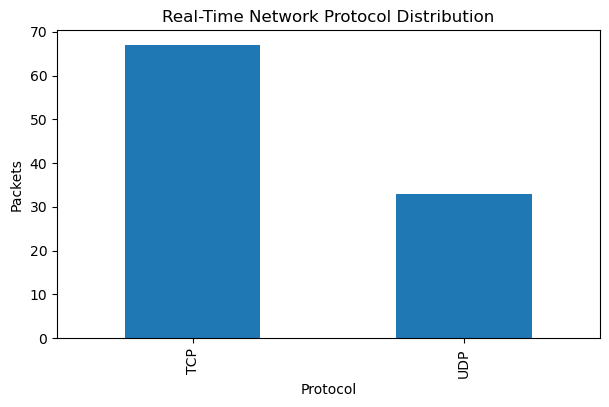

In [6]:
#Protocol graph
import matplotlib.pyplot as plt

df["Protocol"].value_counts().plot(
    kind="bar",
    figsize=(7, 4)
)

plt.title("Real-Time Network Protocol Distribution")
plt.xlabel("Protocol")
plt.ylabel("Packets")
plt.show()

In [9]:
#Most active destination IPs
df["Destination_IP"].value_counts().head(10)

Destination_IP
192.168.0.102      48
104.18.32.47       22
23.212.254.82      13
20.42.65.90         8
172.64.148.235      5
192.168.0.1         3
142.251.150.119     1
Name: count, dtype: int64

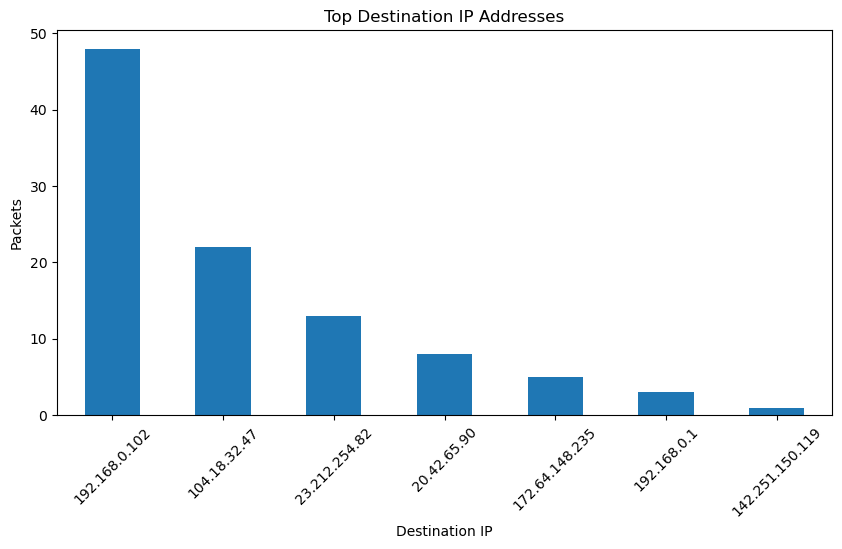

In [10]:
df["Destination_IP"].value_counts().head(10).plot(
    kind="bar",
    figsize=(10, 5)
)

plt.title("Top Destination IP Addresses")
plt.xlabel("Destination IP")
plt.ylabel("Packets")
plt.xticks(rotation=45)
plt.show()

In [13]:
from sklearn.ensemble import IsolationForest

features = df[[
    "Source_Port",
    "Destination_Port",
    "Packet_Size"
]].copy()

model = IsolationForest(
    contamination=0.05,
    random_state=42
)

df["Prediction"] = model.fit_predict(features)

df.head()

,Time,Source_IP,Destination_IP,Protocol,Source_Port,Destination_Port,Packet_Size,Prediction
0,2026-08-02 00:18:30.402160,192.168.0.102,23.212.254.82,UDP,51110,443,71,1
1,2026-08-02 00:18:30.455916,23.212.254.82,192.168.0.102,UDP,443,51110,66,1
2,2026-08-02 00:18:30.657630,192.168.0.102,23.212.254.82,UDP,51110,443,71,1
3,2026-08-02 00:18:30.664874,23.212.254.82,192.168.0.102,UDP,443,51110,66,1
4,2026-08-02 00:18:30.692253,192.168.0.102,23.212.254.82,UDP,51110,443,74,1


In [14]:
#create Status
df["Status"] = df["Prediction"].map({
    1: "Normal",
    -1: "Suspicious"
})

df[[
    "Source_IP",
    "Destination_IP",
    "Protocol",
    "Packet_Size",
    "Status"
]].head(20)

,Source_IP,Destination_IP,Protocol,Packet_Size,Status
0,192.168.0.102,23.212.254.82,UDP,71,Normal
1,23.212.254.82,192.168.0.102,UDP,66,Normal
2,192.168.0.102,23.212.254.82,UDP,71,Normal
3,23.212.254.82,192.168.0.102,UDP,66,Normal
4,192.168.0.102,23.212.254.82,UDP,74,Normal
5,23.212.254.82,192.168.0.102,UDP,66,Normal
6,192.168.0.102,23.212.254.82,UDP,71,Normal
7,172.64.148.235,192.168.0.102,TCP,78,Normal
8,192.168.0.102,172.64.148.235,TCP,82,Normal
9,172.64.148.235,192.168.0.102,TCP,54,Normal


In [16]:
#Show only suspicious traffic
suspicious = df[df["Status"] == "Suspicious"]

suspicious

,Time,Source_IP,Destination_IP,Protocol,Source_Port,Destination_Port,Packet_Size,Prediction,Status
32,2026-08-02 00:18:34.010679,192.168.0.102,192.168.0.1,UDP,60913,53,71,-1,Suspicious
51,2026-08-02 00:18:34.048733,192.168.0.1,192.168.0.102,UDP,53,55188,149,-1,Suspicious
52,2026-08-02 00:18:34.052645,192.168.0.1,192.168.0.102,UDP,53,60913,103,-1,Suspicious
75,2026-08-02 00:18:35.119554,104.18.32.47,192.168.0.102,TCP,443,53467,1197,-1,Suspicious


In [17]:
print("Normal Packets:",
      (df["Status"] == "Normal").sum())

print("Suspicious Packets:",
      (df["Status"] == "Suspicious").sum())

Normal Packets: 96
Suspicious Packets: 4


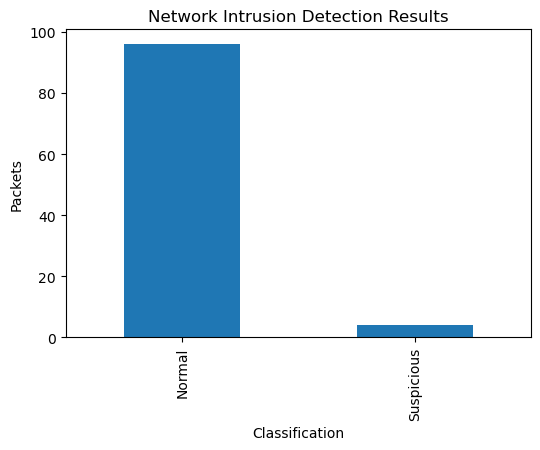

In [18]:
#Visualize detection results
df["Status"].value_counts().plot(
    kind="bar",
    figsize=(6,4)
)
plt.title("Network Intrusion Detection Results")
plt.xlabel("Classification")
plt.ylabel("Packets")
plt.show()

In [ ]:
Save the session